# seaborn 히트맵 — 상관관계 시각화 

- 숫자 컬럼 2개짜리 단순 히트맵을 넘어, **범주형 데이터를 숫자로 바꿔서(원-핫 인코딩)** 상관관계를 확장
- `ORDER_DATE`에서 **요일**을 뽑아내 "요일 x 카테고리" 조합의 주문 패턴을 히트맵으로 구현
- `clustermap`으로 "비슷하게 움직이는 카테고리끼리 자동으로 묶어서" 보는 법

In [3]:
import os
from dotenv import load_dotenv
import oracledb
import pandas as pd
import numpy as np

load_dotenv()

DB_USER = os.getenv("DB_USER")
PASSWORD = os.getenv("PASSWORD")
DSN = os.getenv("DSN")

with oracledb.connect(user=DB_USER, password=PASSWORD, dsn=DSN) as conn:
    df = pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)
# with 블록을 벗어나는 순간 자동으로 연결이 닫힘

df["ORDER_DATE"] = pd.to_datetime(df["ORDER_DATE"])
print(f"전체 주문 데이터 : {len(df)}건")
df.head()

전체 주문 데이터 : 37건


C:\Users\lkw\AppData\Local\Temp\ipykernel_25104\2547616812.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)


,ORDER_ID,MENU_NAME,CATEGORY,PRICE,RATING,REGION,ORDER_DATE
0,1,떡볶이,분식,9000,4.5,강남구,2026-08-01
1,2,치킨,치킨,22000,4.8,서초구,2026-08-02
2,3,피자,피자,25000,4.2,강남구,2026-08-03
3,4,짜장면,중식,8000,4.0,송파구,2026-08-04
4,5,마라탕,중식,13000,4.6,강남구,2026-08-05


In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rc('font', family='AppleGothic')
mpl.rc('axes', unicode_minus=False)

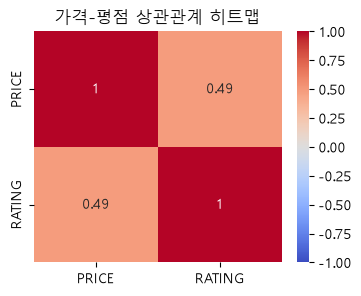

In [5]:
# 숫자 컬럼 2개

numeric_df = df[["PRICE", "RATING"]]
corr_matrix = numeric_df.corr()

plt.figure(figsize = (4,3))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("가격-평점 상관관계 히트맵")
plt.show()

In [6]:
# 카테고리를 숫자로 바꿔서(원-핫 인코딩) 상관관계 살펴보기
# ex) 주문이 치킨이면 1, 아니면 0
# CATEGORY를 0/1 더미 변수로 변환

category_dummies = pd.get_dummies(df["CATEGORY"], prefix="CAT")
print("=== 원-핫 인코딩 결과(앞 5행) ===")
print(category_dummies.head())

print(df["CATEGORY"].value_counts())

# 원본 숫자 컬럼(PRICEM RATING)과 더미 컬럼을 옆으로 이어붙임
# axis = 1 열을 새로 생성하여 결과값 추가
extended_df = pd.concat([df[["PRICE", "RATING"]], category_dummies], axis=1)
extended_corr = extended_df.corr()
print(extended_df)

print("\n=== 확장된 상관관계 행렬 shape ===")
print(extended_corr.shape)

=== 원-핫 인코딩 결과(앞 5행) ===
   CAT_분식  CAT_일식  CAT_중식  CAT_치킨  CAT_피자
0    True   False   False   False   False
1   False   False   False    True   False
2   False   False   False   False    True
3   False   False    True   False   False
4   False   False    True   False   False
CATEGORY
중식    10
일식     8
분식     7
치킨     6
피자     6
Name: count, dtype: int64
    PRICE  RATING  CAT_분식  CAT_일식  CAT_중식  CAT_치킨  CAT_피자
0    9000     4.5    True   False   False   False   False
1   22000     4.8   False   False   False    True   False
2   25000     4.2   False   False   False   False    True
3    8000     4.0   False   False    True   False   False
4   13000     4.6   False   False    True   False   False
5   11000     4.3   False    True   False   False   False
6   18000     4.4   False   False    True   False   False
7    8500     4.3    True   False   False   False   False
8    7000     4.1    True   False   False   False   False
9   21000     4.7   False   False   False    True   False
10  2

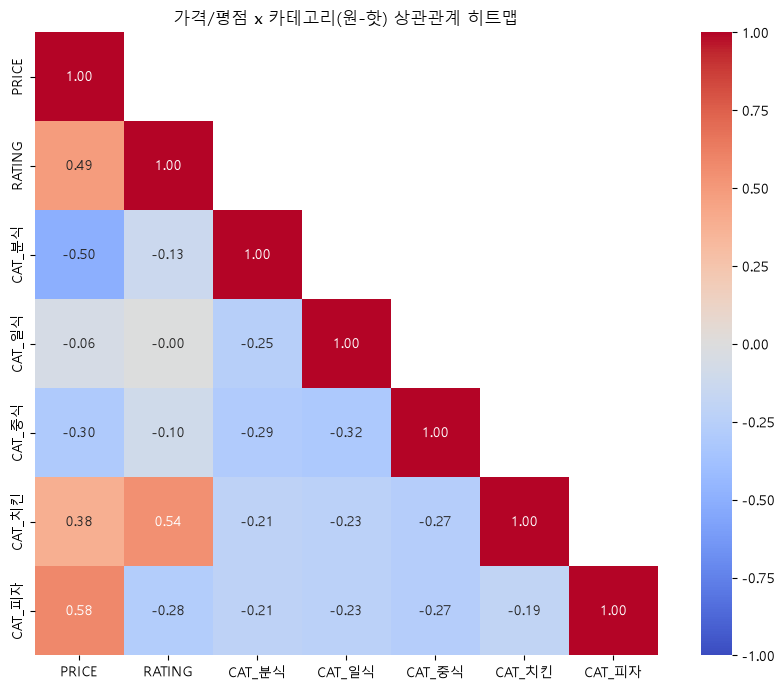

In [7]:
# mask로 대각선 위쪽(중복되는 절반)을 가려서 아래쪽 절반만 보이게 처리함
# np.triu:triangle upper -> 위쪽 삼각형만 남기고 나머지는 지움

mask = np.triu(np.ones_like(extended_corr, dtype = bool), k = 1)   # 모두 True

plt.figure(figsize=(9,7))
sns.heatmap(
    extended_corr, 
    mask=mask,                  # 위쪽 절반 숨기기 (대칭이라 중복이므로)
    annot=True,                 # 각 칸에 데이터 값을 숫자로 표시해줘
    fmt=".2f",
    cmap="coolwarm", 
    vmin=-1, vmax=1, 
    square=True,
)

plt.title("가격/평점 x 카테고리(원-핫) 상관관계 히트맵")
plt.tight_layout()
plt.show()

In [8]:
# 요일 x 카테고리 - 주문 패턴 피벗 히트맵
# ORDER_DATE에서 **요일**을 뽑아내어 "무슨 요일에 어떤 메뉴가 잘 팔리는지" 패턴

# 요일 컬럼 추가
weekday_map = {
    "Monday":"월", 
    "Tuesday":"화", 
    "Wednesday":"수",
    "Thursday":"목", 
    "Friday":"금", 
    "Saturday":"토", 
    "Sunday":"일",
}

# 영어 요일명을 한글로 매핑
df["요일"]= df["ORDER_DATE"].dt.day_name().map(weekday_map)
df.head()

# 원래 금 목 수 월 일 토 화 (가나다라 순서로 나옴)
# pd.Categorical(..., categories=weekday_order, ordered=True) -> categories=["월","화","수","목","금","토","일"] → "이 순서가 진짜 순서다"라고 pandas에 알려줌
weekday_order = ["월", "화", "수", "목", "금", "토", "일"]
df["요일"] = pd.Categorical(df["요일"], categories=weekday_order, ordered=True)


# 요일 x 카테고리별 주문 건수 피벗
# ORDER_ID를 세어서 건수를 구함
weekday_category_pivot = pd.pivot_table(
    df, index="요일", columns="CATEGORY", values="ORDER_ID", 
    aggfunc="count", fill_value=0, observed=False,
)
print(weekday_category_pivot)

CATEGORY  분식  일식  중식  치킨  피자
요일                          
월          0   0   0   2   3
화          0   1   2   0   2
수          0   1   4   0   0
목          1   1   2   1   0
금          0   2   2   0   1
토          4   3   0   0   0
일          2   0   0   3   0


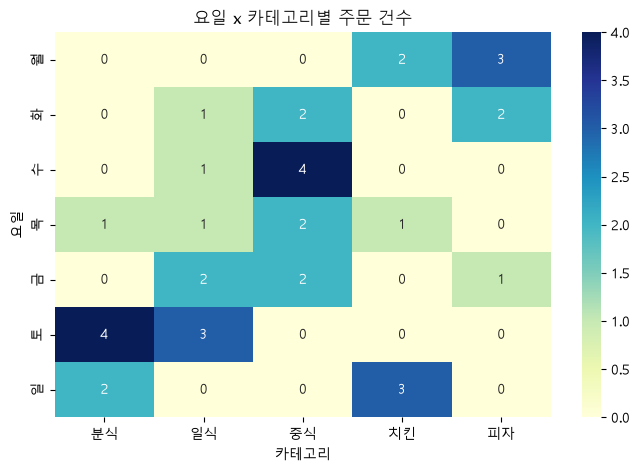

In [9]:
plt.figure(figsize=(8,5))
sns.heatmap(weekday_category_pivot, annot=True, fmt="d", cmap="YlGnBu")
plt.title("요일 x 카테고리별 주문 건수")
plt.ylabel("요일")
plt.xlabel("카테고리")
plt.show()

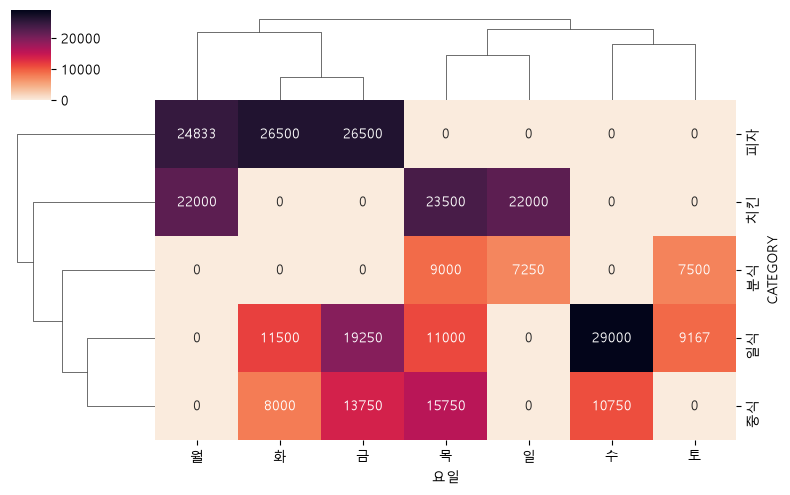

In [10]:
# clustermap - 비슷한 카테고리끼리 자동으로 묶어보기

## clustermap — 비슷한 카테고리끼리 자동으로 묶어보기
"""
`clustermap`은 일반 히트맵과 달리, **행/열의 순서를 데이터가 비슷한 것끼리 자동으로 재배치**
"비슷하게 움직이는 애들끼리 자동으로 옆자리에 앉혀주는 것"이라고 생각

필수 개념은 아니지만, 데이터가 많아질 때 히트맵만으로는 안 보이던 그룹 구조를 발견하는 데 유용
"""

# 카테고리별 X 요일별 평균 가격으로 clustermap 그려보기
weekday_price_pivot = pd.pivot_table(
    df, index="CATEGORY", columns="요일", values="PRICE", 
    aggfunc="mean", fill_value=0, observed=False,
)

sns.clustermap(weekday_price_pivot, annot = True, fmt=".0f", cmap="rocket_r", figsize=(8,5))